# МФК «Математическая статистика и анализ данных»

В работе исследуются задержки внутренних авиарейсов из аэропортов Нью-Йорка за 2013 год. Перед анализом удалены все строки, где есть хотя бы одно пропущенное значение. Файл имеет расширение .xls, по структуре это CSV-таблица

In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, silhouette_score
from sklearn.cluster import KMeans


In [11]:
df = pd.read_csv("flights_NY.csv")


In [13]:
df.head(100)


,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2013,1,1,746.0,0.0,1119.0,-10.0,UA,N24224,1668,EWR,SFO,373.0,2565
96,2013,1,1,749.0,39.0,939.0,49.0,MQ,N508MQ,3737,EWR,ORD,148.0,719
97,2013,1,1,752.0,-3.0,1041.0,-18.0,DL,N325US,2263,LGA,MCO,140.0,950
98,2013,1,1,752.0,2.0,1025.0,-4.0,UA,N511UA,477,LGA,DEN,249.0,1620


In [15]:
df = df.dropna()
df.shape


(327346, 14)

## 1. Вероятность задержки вылета

Выбираю авиакомпании, которые использовали больше 200 разных самолетов. Вероятность задержки оцениваю как долю рейсов, у которых `dep_delay > 0`.


In [17]:
result = df.groupby('carrier').agg(
    n_planes=('tailnum', 'nunique'),
    flights=('flight', 'size'),
    delay_probability=('dep_delay', lambda x: (x > 0).mean())
)

result = result[result['n_planes'] > 200]
result = result.sort_values('n_planes', ascending=False)
result


,n_planes,flights,delay_probability
carrier,,,
DL,626,47658,0.318645
UA,620,57782,0.469437
AA,600,31947,0.316305
WN,581,12044,0.542594
EV,316,51108,0.449558
US,289,19831,0.240129
MQ,237,25037,0.318169
9E,203,17294,0.403608


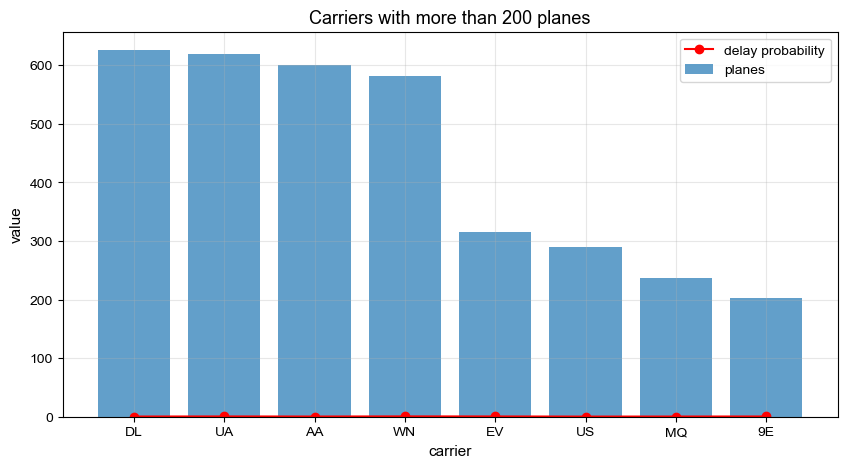

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(result.index, result['n_planes'], alpha=0.7, label='planes')
plt.plot(result.index, result['delay_probability'], color='red', marker='o', label='delay probability')
plt.xlabel('carrier')
plt.ylabel('value')
plt.title('Carriers with more than 200 planes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Наибольшая оценка вероятности задержки получилась у авиакомпании **WN**. При этом сортировка на графике идет по числу самолетов, как требовалось в задании.


## 2. Среднее время самолета в воздухе

Для каждого самолета считаю среднее значение `air_time`. После этого строю гистограмму и накладываю плотность нормального распределения с параметрами, оцененными по выборке.


In [21]:
plane_air_time = df.groupby('tailnum')['air_time'].mean()

mu = plane_air_time.mean()
sigma = plane_air_time.std(ddof=1)
interval = stats.norm.interval(0.95, loc=mu, scale=sigma)

pd.DataFrame({
    'value': [len(plane_air_time), mu, sigma, interval[0], interval[1]]
}, index=['n_planes', 'mu', 'sigma', 'low_95', 'high_95'])


,value
n_planes,4037.000000
mu,157.496640
sigma,75.804998
low_95,8.921574
high_95,306.071706


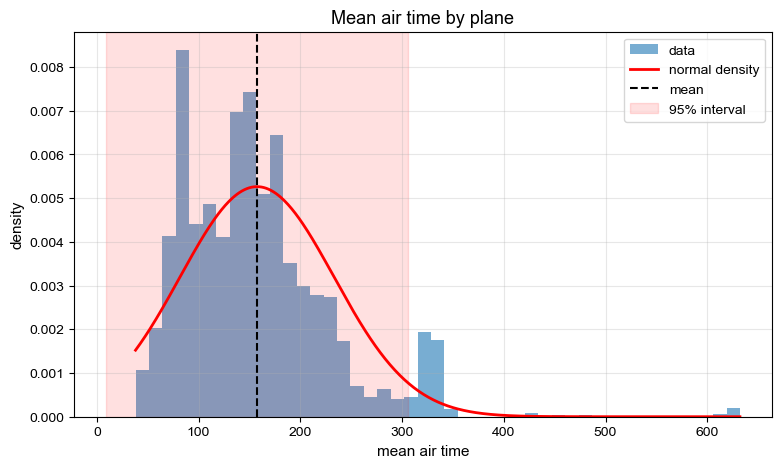

In [23]:
x = np.linspace(plane_air_time.min(), plane_air_time.max(), 500)
y = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(9, 5))
plt.hist(plane_air_time, bins=45, density=True, alpha=0.6, label='data')
plt.plot(x, y, color='red', linewidth=2, label='normal density')
plt.axvline(mu, color='black', linestyle='--', label='mean')
plt.axvspan(interval[0], interval[1], color='red', alpha=0.12, label='95% interval')
plt.xlabel('mean air time')
plt.ylabel('density')
plt.title('Mean air time by plane')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Оцененное среднее время в воздухе около **157.5 минут**, стандартное отклонение около **75.8 минут**. Если принять нормальную модель, то для 95% самолетов среднее время лежит примерно от **8.9** до **306.1 минут**.


## 3. Сравнение WN и UA

Сначала считаю скорость каждого рейса как `distance / air_time * 60`, затем для каждого самолета внутри авиакомпании нахожу среднюю скорость. Сравниваю распределения средних скоростей для WN и UA.


In [25]:
df['speed'] = df['distance'] / df['air_time'] * 60

speed_by_plane = df.groupby(['carrier', 'tailnum']).agg(
    mean_speed=('speed', 'mean'),
    n_flights=('flight', 'size')
).reset_index()

wn = speed_by_plane[speed_by_plane['carrier'] == 'WN']['mean_speed']
ua = speed_by_plane[speed_by_plane['carrier'] == 'UA']['mean_speed']

wn_ci = stats.t.interval(0.95, len(wn) - 1, loc=wn.mean(), scale=stats.sem(wn))
ua_ci = stats.t.interval(0.95, len(ua) - 1, loc=ua.mean(), scale=stats.sem(ua))

ks_test = stats.ks_2samp(wn, ua)
t_test = stats.ttest_ind(wn, ua, equal_var=False)

summary = pd.DataFrame({
    'carrier': ['WN', 'UA'],
    'n': [len(wn), len(ua)],
    'mean': [wn.mean(), ua.mean()],
    'ci_low': [wn_ci[0], ua_ci[0]],
    'ci_high': [wn_ci[1], ua_ci[1]]
})

tests = pd.DataFrame({
    'test': ['Kolmogorov-Smirnov', 'Welch t-test'],
    'statistic': [ks_test.statistic, t_test.statistic],
    'p_value': [ks_test.pvalue, t_test.pvalue]
})

display(summary)
display(tests)


,carrier,n,mean,ci_low,ci_high
0,WN,581,397.644026,396.475424,398.812628
1,UA,620,423.366298,421.931746,424.800849


,test,statistic,p_value
0,Kolmogorov-Smirnov,0.678674,4.126460e-132
1,Welch t-test,-27.301769,2.792906e-127


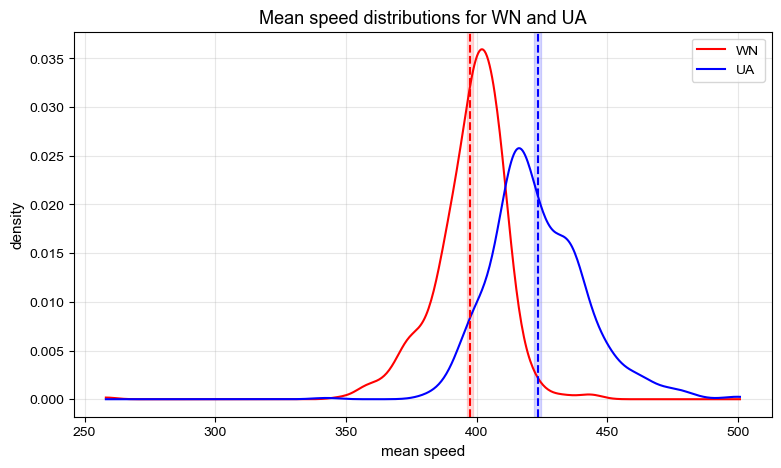

In [27]:
x = np.linspace(min(wn.min(), ua.min()), max(wn.max(), ua.max()), 500)
wn_density = stats.gaussian_kde(wn)(x)
ua_density = stats.gaussian_kde(ua)(x)

plt.figure(figsize=(9, 5))
plt.plot(x, wn_density, color='red', label='WN')
plt.plot(x, ua_density, color='blue', label='UA')
plt.axvline(wn.mean(), color='red', linestyle='--')
plt.axvline(ua.mean(), color='blue', linestyle='--')
plt.axvspan(wn_ci[0], wn_ci[1], color='red', alpha=0.15)
plt.axvspan(ua_ci[0], ua_ci[1], color='blue', alpha=0.15)
plt.xlabel('mean speed')
plt.ylabel('density')
plt.title('Mean speed distributions for WN and UA')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Распределения отличаются значимо: p-value критерия Колмогорова-Смирнова очень мало. Средняя скорость у UA выше, а доверительные интервалы для средних WN и UA не пересекаются.


## 4. Регрессия средней дальности по средней скорости

Для каждого самолета считаю среднюю скорость и среднюю дальность рейса. Обычная линейная модель показывает общий рост, но зависимость нелинейная, поэтому использую полиномиальные признаки.


In [29]:
plane_stats = df.groupby('tailnum').agg(
    mean_speed=('speed', 'mean'),
    mean_distance=('distance', 'mean'),
    n_flights=('flight', 'size')
).reset_index()

quality = []

for degree in [1, 2, 3]:
    model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), LinearRegression())
    model.fit(plane_stats[['mean_speed']], plane_stats['mean_distance'])
    pred = model.predict(plane_stats[['mean_speed']])
    quality.append([degree, r2_score(plane_stats['mean_distance'], pred), mean_squared_error(plane_stats['mean_distance'], pred) ** 0.5])

quality = pd.DataFrame(quality, columns=['degree', 'R2', 'RMSE'])
quality


,degree,R2,RMSE
0,1,0.625381,371.896044
1,2,0.745029,306.811860
2,3,0.756273,299.970549


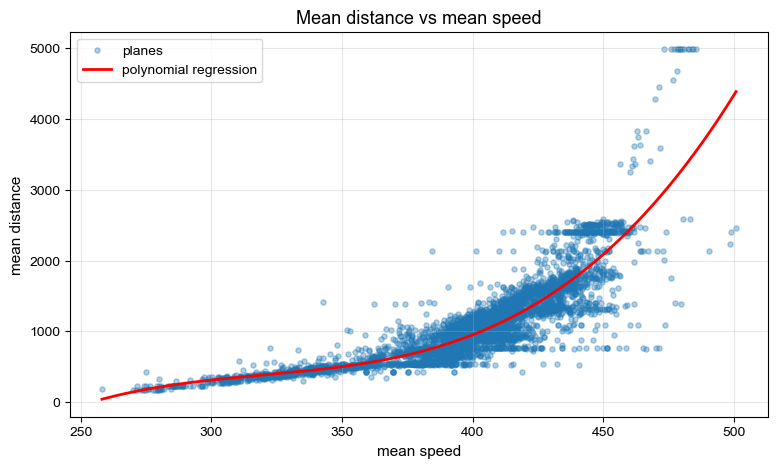

In [37]:
model = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression())
model.fit(plane_stats[['mean_speed']], plane_stats['mean_distance'])

x = np.linspace(plane_stats['mean_speed'].min(), plane_stats['mean_speed'].max(), 400)
y = model.predict(pd.DataFrame({'mean_speed': x}))

plt.figure(figsize=(9, 5))
plt.scatter(plane_stats['mean_speed'], plane_stats['mean_distance'], s=14, alpha=0.35, label='planes')
plt.plot(x, y, color='red', linewidth=2, label='polynomial regression')
plt.xlabel('mean speed')
plt.ylabel('mean distance')
plt.title('Mean distance vs mean speed')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Полином третьей степени дает лучший результат среди трех проверенных вариантов. По графику видно, что самолеты с большей средней скоростью обычно летают на более дальние расстояния.


## 5. Кластеризация самолетов

Кластеризую самолеты по двум признакам: средней скорости и числу выполненных рейсов. Перед KMeans признаки стандартизируются, потому что они измеряются в разных шкалах.


In [41]:
cluster_data = plane_stats[['tailnum', 'mean_speed', 'n_flights']].copy()

X = cluster_data[['mean_speed', 'n_flights']].values
X = (X - X.mean(axis=0)) / X.std(axis=0)

def my_kmeans(X, k, n_iter=100, random_state=42):
    np.random.seed(random_state)
    centers = X[np.random.choice(len(X), k, replace=False)]

    for i in range(n_iter):
        distances = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        labels = distances.argmin(axis=1)

        new_centers = np.array([
            X[labels == j].mean(axis=0) if np.any(labels == j) else centers[j]
            for j in range(k)
        ])

        if np.allclose(centers, new_centers):
            break

        centers = new_centers

    return labels, centers

def my_silhouette(X, labels):
    values = []

    for i in range(len(X)):
        same = labels == labels[i]
        other_clusters = [c for c in np.unique(labels) if c != labels[i]]

        if same.sum() > 1:
            a = np.sqrt(((X[i] - X[same]) ** 2).sum(axis=1)).sum() / (same.sum() - 1)
        else:
            a = 0

        b = min(
            np.sqrt(((X[i] - X[labels == c]) ** 2).sum(axis=1)).mean()
            for c in other_clusters
        )

        values.append((b - a) / max(a, b))

    return np.mean(values)

scores = []
for k in range(2, 7):
    labels, centers = my_kmeans(X, k)
    scores.append([k, my_silhouette(X, labels)])

scores = pd.DataFrame(scores, columns=['k', 'silhouette'])
scores


,k,silhouette
0,2,0.518840
1,3,0.528430
2,4,0.382250
3,5,0.434740
4,6,0.391615


In [44]:
labels, centers = my_kmeans(X, 3)
cluster_data['cluster'] = labels

cluster_summary = cluster_data.groupby('cluster').agg(
    n=('tailnum', 'size'),
    mean_speed=('mean_speed', 'mean'),
    mean_flights=('n_flights', 'mean'),
    min_flights=('n_flights', 'min'),
    max_flights=('n_flights', 'max')
)

cluster_summary


,n,mean_speed,mean_flights,min_flights,max_flights
cluster,,,,,
0,521,328.211890,54.234165,1,264
1,587,388.241264,247.916525,137,544
2,2929,413.121270,52.428474,1,180


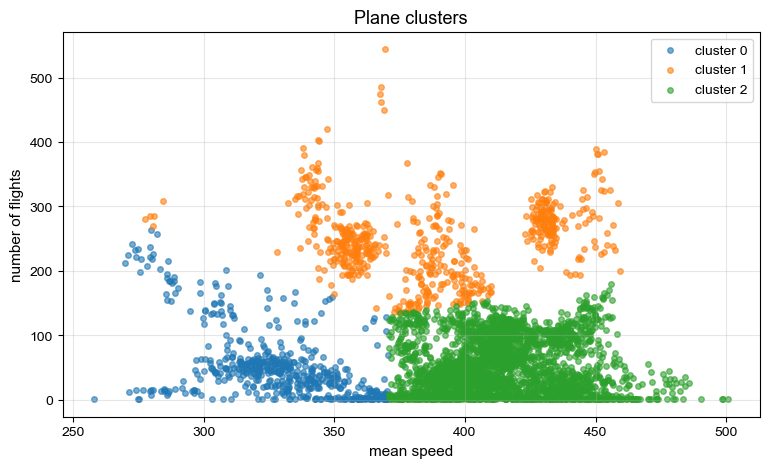

In [46]:
plt.figure(figsize=(9, 5))

for cluster in sorted(cluster_data['cluster'].unique()):
    part = cluster_data[cluster_data['cluster'] == cluster]
    plt.scatter(part['mean_speed'], part['n_flights'], s=16, alpha=0.6, label=f'cluster {cluster}')

plt.xlabel('mean speed')
plt.ylabel('number of flights')
plt.title('Plane clusters')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


По значению silhouette удобнее всего взять 3 кластера. Один кластер содержит основную массу самолетов с обычной скоростью и небольшим или средним числом рейсов. Второй кластер выделяет более медленные самолеты, которые, вероятно, чаще работали на коротких направлениях. Третий кластер отличается большим числом выполненных рейсов, то есть в него попали наиболее активно использовавшиеся борта.

Интерпретация не является строгой классификацией типов самолетов, потому что в модели использованы только два признака. Но по этим двум признакам группы выглядят осмысленно: скорость отделяет короткие и более дальние направления, а число рейсов показывает интенсивность использования самолета.


## Итог

В работе выполнены все пять заданий. Самая большая вероятность задержки среди крупных авиакомпаний получилась у WN. Средние скорости WN и UA различаются статистически значимо. Средняя дальность рейса связана со средней скоростью самолета, а кластеризация отделяет группы самолетов по скорости и интенсивности использования.
